**Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

**Load Dataset**

In [ ]:
df = pd.read_csv("/content/pendatang_clean.csv")

**Dataset Overview**

In [ ]:
df.shape

(28177, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28177 entries, 0 to 28176
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  28177 non-null  int64 
 1   destination_city      28177 non-null  object
 2   destination_district  28177 non-null  object
 3   destination_village   28177 non-null  object
 4   origin_province       28177 non-null  object
 5   origin_city           28177 non-null  object
 6   total_migrants        28177 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 1.5+ MB


In [ ]:
df.describe()

,year,total_migrants
count,28177.0,28177.000000
mean,2025.0,3.915498
std,0.0,7.355773
min,2025.0,1.000000
25%,2025.0,1.000000
50%,2025.0,2.000000
75%,2025.0,4.000000
max,2025.0,260.000000


In [ ]:
print("="*50)
print("PROJECT OVERVIEW")
print("="*50)

print(f"Total Migrants          : {df['total_migrants'].sum():,}")
print(f"Origin Provinces        : {df['origin_province'].nunique()}")
print(f"Origin Cities           : {df['origin_city'].nunique()}")
print(f"Destination Cities      : {df['destination_city'].nunique()}")
print(f"Destination Districts   : {df['destination_district'].nunique()}")
print(f"Destination Villages    : {df['destination_village'].nunique()}")

PROJECT OVERVIEW
Total Migrants          : 110,327
Origin Provinces        : 38
Origin Cities           : 508
Destination Cities      : 6
Destination Districts   : 44
Destination Villages    : 267


**Total Pendatang**

In [ ]:
total = df["total_migrants"].sum()
print(f"Total Pendatang : {total:,}")

Total Pendatang : 110,327


Business Question 1

How many migrants moved to DKI Jakarta?

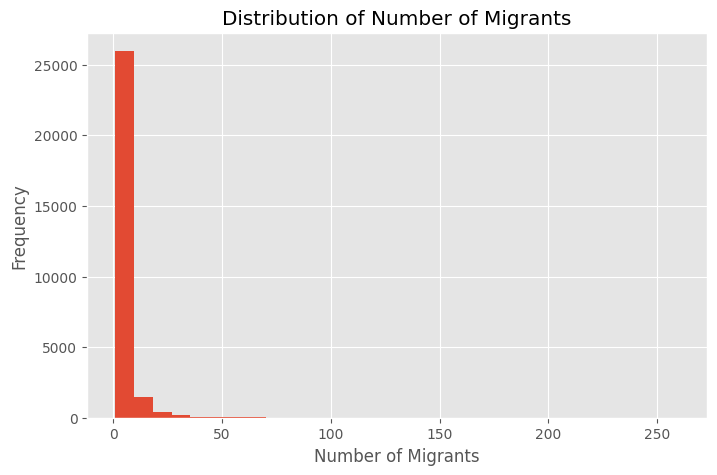

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["total_migrants"], bins=30)
plt.title("Distribution of Number of Migrants")
plt.xlabel("Number of Migrants")
plt.ylabel("Frequency")

plt.show()

Business Question 2

Which provinces contribute the highest and lowest number of migrants to DKI Jakarta?

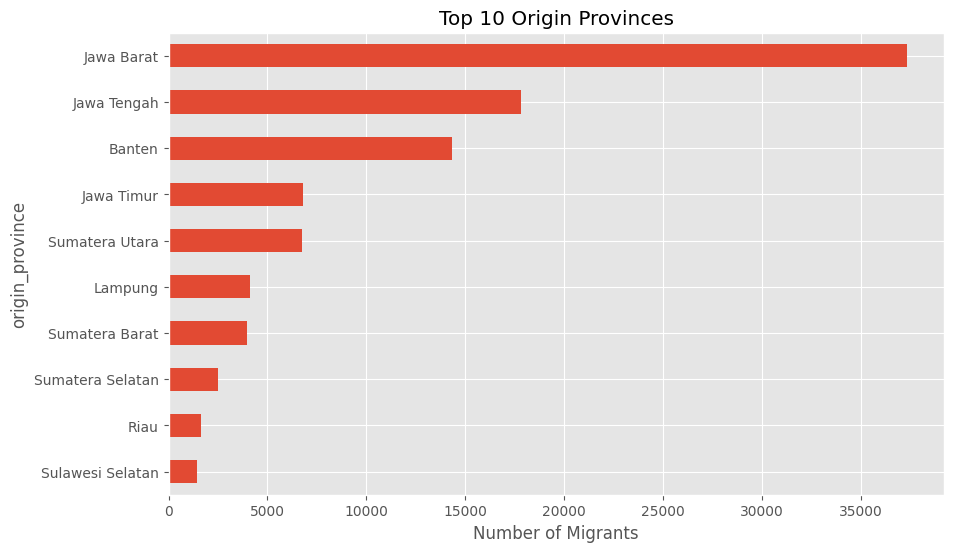

In [ ]:
plt.figure(figsize=(10,6))
province.sort_values().plot(kind="barh")
plt.title("Top 10 Origin Provinces")
plt.xlabel("Number of Migrants")

plt.show()

In [ ]:
province = (
    df.groupby("origin_province")["total_migrants"]
      .sum()
      .sort_values(ascending=False)
)

(province / province.sum() * 100).head(10)

,total_migrants
origin_province,
Jawa Barat,33.836685
Jawa Tengah,16.156517
Banten,12.979597
Jawa Timur,6.184343
Sumatera Utara,6.105486
Lampung,3.744324
Sumatera Barat,3.611083
Sumatera Selatan,2.277774
Riau,1.479239


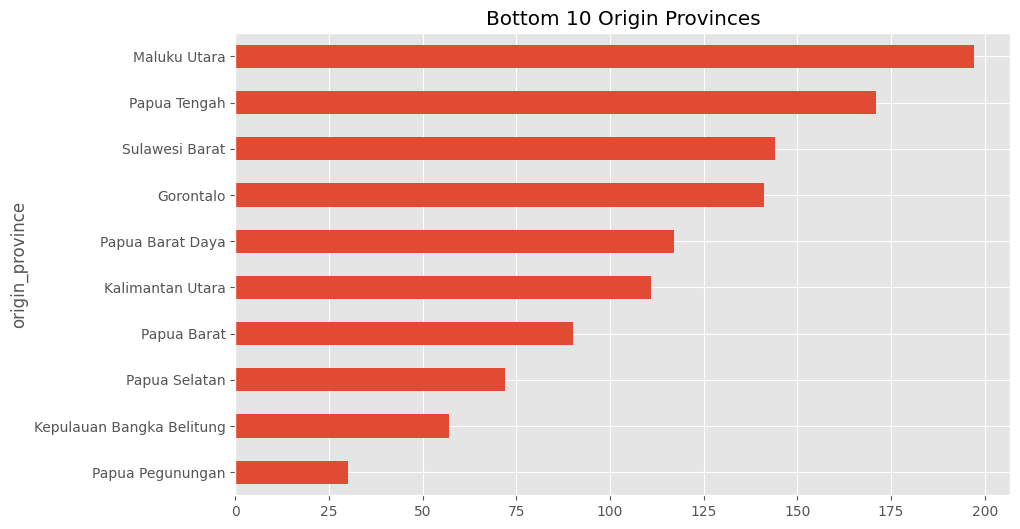

In [ ]:
bottom = (
    df.groupby("origin_province")["total_migrants"]
      .sum()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(10,6))
bottom.plot(kind="barh")
plt.title("Bottom 10 Origin Provinces")

plt.show()

Business Question 3

Which cities/regencies contribute the highest number of migrants?

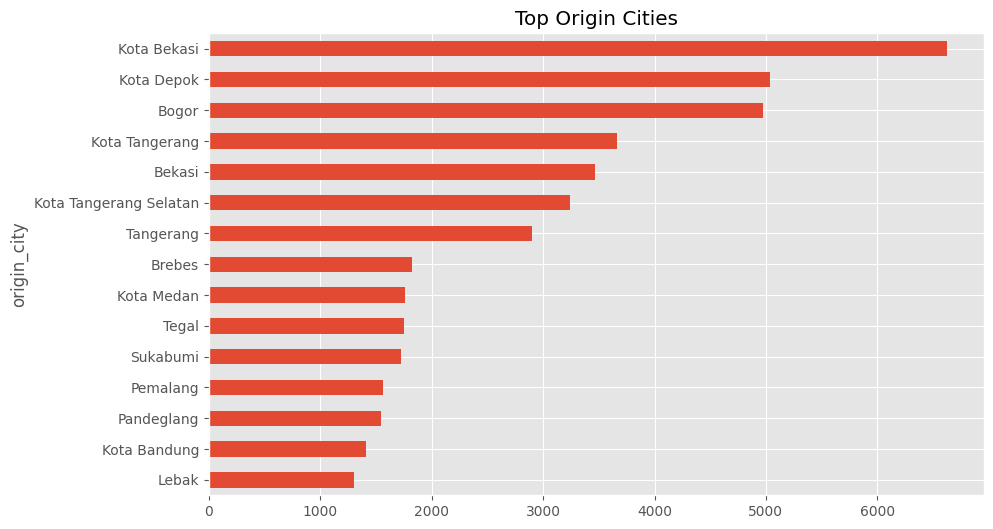

In [ ]:
city = (
    df.groupby("origin_city")["total_migrants"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))
city.sort_values().plot(kind="barh")
plt.title("Top Origin Cities")

plt.show()

Business Question 4

Which administrative city receives the highest number of migrants?

In [ ]:
destination = (
    df.groupby("destination_city")["total_migrants"]
      .sum()
      .sort_values(ascending=False)
)

destination

,total_migrants
destination_city,
Kota Adm. Jakarta Timur,32199
Kota Adm. Jakarta Selatan,25218
Kota Adm. Jakarta Barat,24887
Kota Adm. Jakarta Utara,17663
Kota Adm. Jakarta Pusat,10064
Kab. Adm. Kep. Seribu,296


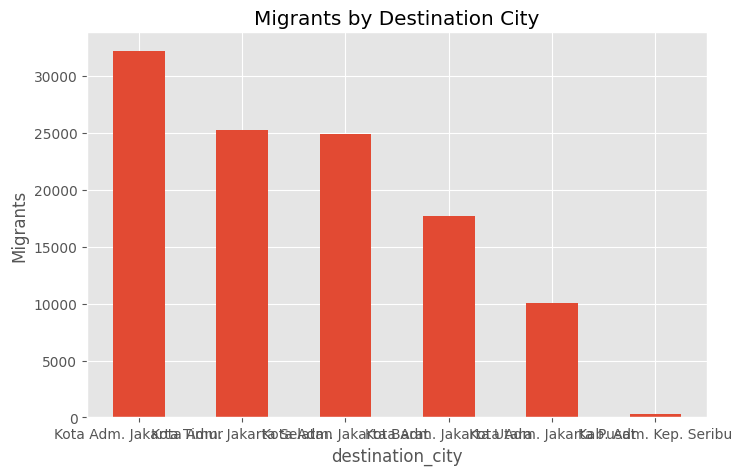

In [ ]:
plt.figure(figsize=(8,5))
destination.plot(kind="bar")
plt.ylabel("Migrants")
plt.title("Migrants by Destination City")
plt.xticks(rotation=0)

plt.show()

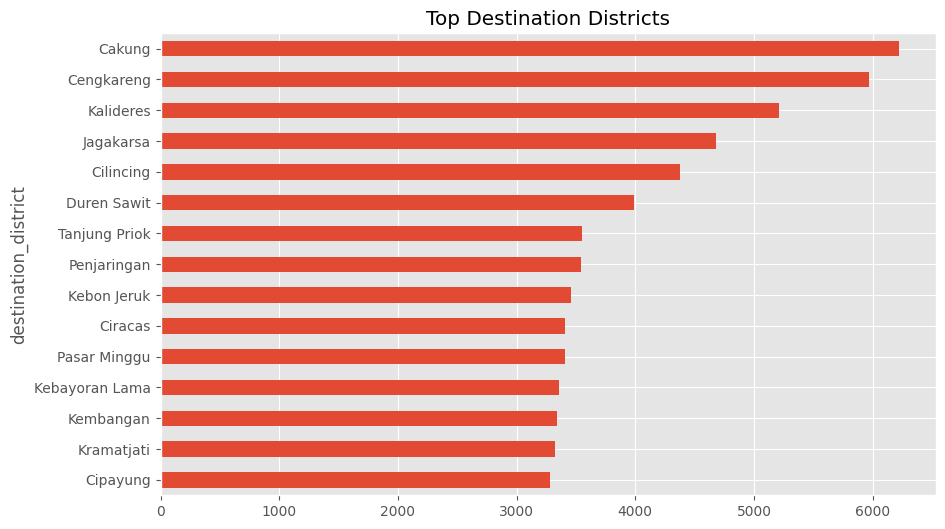

In [ ]:
district = (
    df.groupby("destination_district")["total_migrants"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))
district.sort_values().plot(kind="barh")
plt.title("Top Destination Districts")

plt.show()

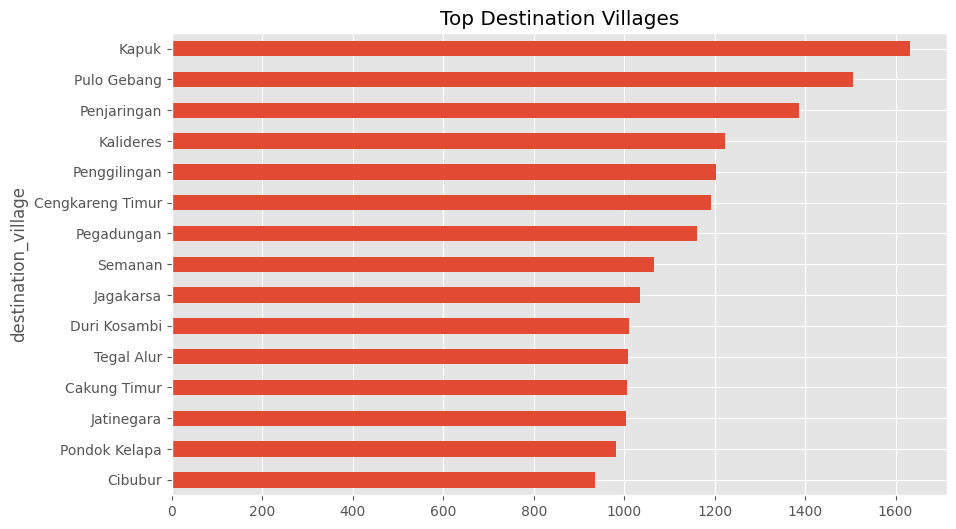

In [ ]:
village = (
    df.groupby("destination_village")["total_migrants"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))
village.sort_values().plot(kind="barh")
plt.title("Top Destination Villages")

plt.show()

**Heatmap Asal → Tujuan**

In [ ]:
pivot = pd.pivot_table(
    df,
    index="origin_province",
    columns="destination_city",
    values="total_migrants",
    aggfunc="sum",
    fill_value=0
)

pivot.head()

destination_city,Kab. Adm. Kep. Seribu,Kota Adm. Jakarta Barat,Kota Adm. Jakarta Pusat,Kota Adm. Jakarta Selatan,Kota Adm. Jakarta Timur,Kota Adm. Jakarta Utara
origin_province,,,,,,
Aceh,1,151,101,260,270,106
Bali,0,91,52,131,121,75
Banten,124,5185,970,3757,2267,2017
Bengkulu,0,125,64,151,183,70
Daerah Istimewa Yogyakarta,3,230,129,384,412,100


In [ ]:
top_route = (
    df.groupby(
        ["origin_city","destination_city"]
    )["total_migrants"]
    .sum()
    .reset_index()
    .sort_values(
        "total_migrants",
        ascending=False
    )
)

top_route.head(10)

,origin_city,destination_city,total_migrants
822,Kota Bekasi,Kota Adm. Jakarta Timur,3585
889,Kota Depok,Kota Adm. Jakarta Selatan,2226
890,Kota Depok,Kota Adm. Jakarta Timur,1780
1187,Kota Tangerang Selatan,Kota Adm. Jakarta Selatan,1712
1179,Kota Tangerang,Kota Adm. Jakarta Barat,1672
282,Bogor,Kota Adm. Jakarta Timur,1603
197,Bekasi,Kota Adm. Jakarta Timur,1327
2187,Tangerang,Kota Adm. Jakarta Barat,1268
281,Bogor,Kota Adm. Jakarta Selatan,1243
821,Kota Bekasi,Kota Adm. Jakarta Selatan,1093


**Outlier**

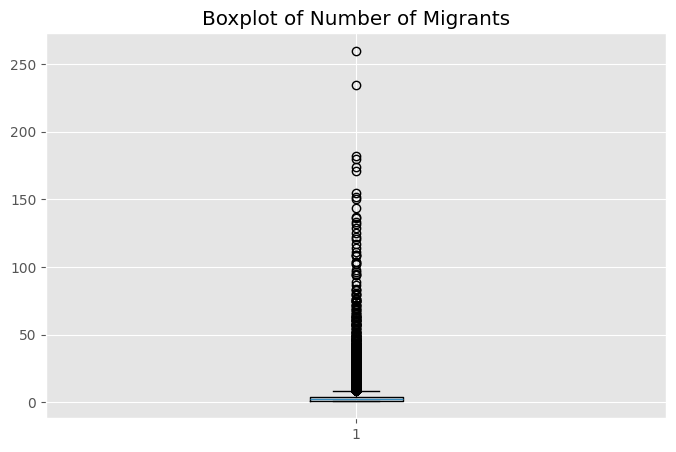

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df["total_migrants"])
plt.title("Boxplot of Number of Migrants")
plt.show()

In [ ]:
top_route = (
    df.groupby(
        ["origin_city","destination_city"]
    )["total_migrants"]
    .sum()
    .reset_index()
    .sort_values(
        "total_migrants",
        ascending=False
    )
)

top_route.head(10)

,origin_city,destination_city,total_migrants
822,Kota Bekasi,Kota Adm. Jakarta Timur,3585
889,Kota Depok,Kota Adm. Jakarta Selatan,2226
890,Kota Depok,Kota Adm. Jakarta Timur,1780
1187,Kota Tangerang Selatan,Kota Adm. Jakarta Selatan,1712
1179,Kota Tangerang,Kota Adm. Jakarta Barat,1672
282,Bogor,Kota Adm. Jakarta Timur,1603
197,Bekasi,Kota Adm. Jakarta Timur,1327
2187,Tangerang,Kota Adm. Jakarta Barat,1268
281,Bogor,Kota Adm. Jakarta Selatan,1243
821,Kota Bekasi,Kota Adm. Jakarta Selatan,1093


In [ ]:
diversity = (
    df.groupby("destination_city")["origin_province"]
      .nunique()
      .sort_values(ascending=False)
)

diversity

,origin_province
destination_city,
Kota Adm. Jakarta Barat,38
Kota Adm. Jakarta Pusat,38
Kota Adm. Jakarta Timur,38
Kota Adm. Jakarta Selatan,38
Kota Adm. Jakarta Utara,38
Kab. Adm. Kep. Seribu,20
